NumPy version: 2.1.3
Matplotlib OK!


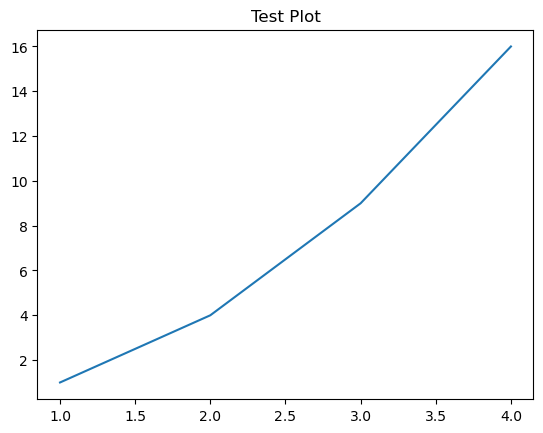

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Matplotlib OK!")

x = [1, 2, 3, 4]
y = [1, 4, 9, 16]

plt.plot(x, y)
plt.title("Test Plot")
plt.show()


In [2]:
import os
import tarfile

cifar_tar = "cifar-10-python.tar.gz"
cifar_folder = "cifar-10-batches-py"

print("Files in current folder:", os.listdir("."))

if os.path.exists(cifar_tar) and not os.path.exists(cifar_folder):
    print("Extracting CIFAR-10...")
    with tarfile.open(cifar_tar, "r:gz") as tar:
        tar.extractall()
    print("Done.")
else:
    print("Archive already extracted or not found.")


Files in current folder: ['.ipynb_checkpoints', 'cifar-10-batches-py', 'cifar-10-python.tar.gz', 'gozaresh.pdf', 'main.ipynb', 'Untitled.ipynb']
Archive already extracted or not found.


In [3]:
import os
print(os.listdir("."))


['.ipynb_checkpoints', 'cifar-10-batches-py', 'cifar-10-python.tar.gz', 'gozaresh.pdf', 'main.ipynb', 'Untitled.ipynb']


In [4]:
import pickle
import numpy as np
import os

cifar_folder = "cifar-10-batches-py"

def load_batch(batch_name):
    with open(os.path.join(cifar_folder, batch_name), "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    data = batch[b"data"]          
    labels = batch[b"labels"]      

    data = data.reshape(-1, 3, 32, 32)
    data = np.transpose(data, (0, 2, 3, 1))
    return data, np.array(labels)

def load_cifar10():
    X_train_list = []
    y_train_list = []

    for i in range(1, 6):
        data, labels = load_batch(f"data_batch_{i}")
        X_train_list.append(data)
        y_train_list.append(labels)

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)

    X_test, y_test = load_batch("test_batch")

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_cifar10()

print("Train images:", X_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)


Train images: (50000, 32, 32, 3)
Train labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


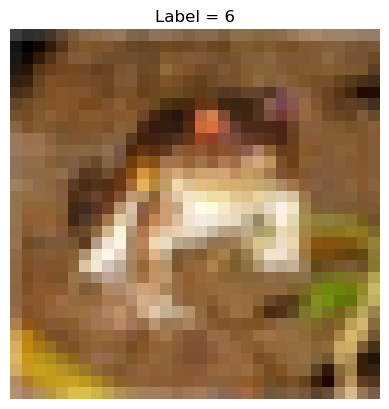

In [5]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0])
plt.title(f"Label = {y_train[0]}")
plt.axis("off")
plt.show()


In [6]:
# Convert to float32 and normalize to [0, 1]
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm  = X_test.astype(np.float32)  / 255.0

print("Train min/max:", X_train_norm.min(), X_train_norm.max())
print("Test  min/max:", X_test_norm.min(), X_test_norm.max())


Train min/max: 0.0 1.0
Test  min/max: 0.0 1.0


In [7]:
N_train = X_train_norm.shape[0]
N_test  = X_test_norm.shape[0]

X_train_flat = X_train_norm.reshape(N_train, -1)  # (50000, 3072)
X_test_flat  = X_test_norm.reshape(N_test, -1)    # (10000, 3072)

print("Flattened train shape:", X_train_flat.shape)
print("Flattened test shape :", X_test_flat.shape)


Flattened train shape: (50000, 3072)
Flattened test shape : (10000, 3072)


In [8]:
num_classes = 10

def to_one_hot(y, num_classes=10):
    N = y.shape[0]
    one_hot = np.zeros((N, num_classes), dtype=np.float32)
    one_hot[np.arange(N), y] = 1.0
    return one_hot

y_train_onehot = to_one_hot(y_train, num_classes)
y_test_onehot  = to_one_hot(y_test, num_classes)

print("y_train shape:", y_train.shape)
print("y_train_onehot shape:", y_train_onehot.shape)


y_train shape: (50000,)
y_train_onehot shape: (50000, 10)


In [9]:
import numpy as np

# For reproducibility (so results don't change every run)
np.random.seed(42)

input_dim = 3072   # 32*32*3
hidden_dim = 128   # you can change later
output_dim = 10    # 10 classes (CIFAR-10)


In [10]:
class ReLU:     #ReLu Function
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, grad_output):
        return grad_output * self.mask


class Sigmoid:   #Sigmoid Function
    def forward(self, x):
        self.out = 1.0 / (1.0 + np.exp(-x))
        return self.out

    def backward(self, grad_output):
        return grad_output * self.out * (1.0 - self.out)


class Tanh:       #Tanh Function
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out

    def backward(self, grad_output):
        return grad_output * (1.0 - self.out ** 2)


In [11]:
def init_weights(shape, method="xavier"):
    fan_in, fan_out = shape

    if method == "random_normal":
        # small normal noise
        return np.random.randn(fan_in, fan_out) * 0.01

    elif method == "xavier":
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        return np.random.uniform(-limit, limit, size=(fan_in, fan_out))

    elif method == "he":
        std = np.sqrt(2.0 / fan_in)
        return np.random.randn(fan_in, fan_out) * std

    else:
        raise ValueError(f"Unknown init method: {method}")


In [12]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])      # shape (2, 2)

B = np.array([[10],
              [20]])        # shape (2, 1)

print("A shape:", A.shape)
print("B shape:", B.shape)

C = A @ B   # matrix multiplication
print("C = A @ B:", C)
print("C shape:", C.shape)


A shape: (2, 2)
B shape: (2, 1)
C = A @ B: [[ 50]
 [110]]
C shape: (2, 1)


In [13]:
class LinearLayer:
    def __init__(self, in_features, out_features, init_method="xavier"):
        # initialize weights
        self.W = init_weights((in_features, out_features), method=init_method)
        self.b = np.zeros((1, out_features), dtype=np.float32)

    def forward(self, x):
        # x shape: (batch_size, in_features)
        self.x = x
        return x @ self.W + self.b

    def backward(self, grad_output, lr):
        # grad_output shape: (batch_size, out_features)
        batch_size = self.x.shape[0]

        # gradients w.r.t. weights, bias, and input
        grad_W = self.x.T @ grad_output / batch_size
        grad_b = grad_output.mean(axis=0, keepdims=True)
        grad_x = grad_output @ self.W.T

        # update weights (SGD)
        self.W -= lr * grad_W
        self.b -= lr * grad_b

        return grad_x


In [14]:
def softmax(logits):
    # logits: (batch_size, num_classes)
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_true_onehot):
    # probs, y_true_onehot: (batch_size, num_classes)
    eps = 1e-12
    clipped = np.clip(probs, eps, 1.0 - eps)
    loss = -np.sum(y_true_onehot * np.log(clipped)) / y_true_onehot.shape[0]
    return loss

def accuracy(probs, y_true):
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y_true)


In [15]:
class MLP_1Hidden:
    def __init__(self, input_dim, hidden_dim, output_dim,
                 activation="relu", init_method="xavier", lr=0.01):
        self.lr = lr

        # choose activation
        if activation == "relu":
            self.act = ReLU()
        elif activation == "sigmoid":
            self.act = Sigmoid()
        elif activation == "tanh":
            self.act = Tanh()
        else:
            raise ValueError("Unknown activation:", activation)

        # layers
        self.fc1 = LinearLayer(input_dim, hidden_dim, init_method=init_method)
        self.fc2 = LinearLayer(hidden_dim, output_dim, init_method=init_method)

    def forward(self, x):
        # x: (batch_size, input_dim)
        z1 = self.fc1.forward(x)
        a1 = self.act.forward(z1)
        z2 = self.fc2.forward(a1)
        probs = softmax(z2)
        # store for potential debugging if needed
        self.cache = (x, z1, a1, z2, probs)
        return probs

    def backward(self, probs, y_true_onehot):
        # gradient of loss wrt logits for softmax + cross-entropy
        batch_size = y_true_onehot.shape[0]
        grad_logits = (probs - y_true_onehot)  # / batch_size already handled in loss scaling if needed

        # backprop through fc2
        grad_a1 = self.fc2.backward(grad_logits, self.lr)

        # backprop through activation
        grad_z1 = self.act.backward(grad_a1)

        # backprop through fc1
        _ = self.fc1.backward(grad_z1, self.lr)


In [16]:
def iterate_minibatches(X, y, batch_size):
    N = X.shape[0]
    indices = np.random.permutation(N)
    for start in range(0, N, batch_size):
        end = start + batch_size
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

def train_model(model, X_train, y_train_onehot, y_train_labels,
                X_val, y_val_onehot, y_val_labels,
                epochs=5, batch_size=128):
    for epoch in range(1, epochs + 1):
        # ---- training ----
        for X_batch, y_batch_onehot in iterate_minibatches(X_train, y_train_onehot, batch_size):
            probs = model.forward(X_batch)
            model.backward(probs, y_batch_onehot)

        # ---- evaluate on train subset + val ----
        train_probs = model.forward(X_train[:5000])  # subset for speed
        val_probs   = model.forward(X_val)

        train_loss = cross_entropy_loss(train_probs, y_train_onehot[:5000])
        val_loss   = cross_entropy_loss(val_probs, y_val_onehot)
        train_acc  = accuracy(train_probs, y_train_labels[:5000])
        val_acc    = accuracy(val_probs, y_val_labels)

        print(f"Epoch {epoch}: "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")


In [17]:
import numpy as np

# 1) Normalize
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm  = X_test.astype(np.float32)  / 255.0

# 2) Flatten: (N, 32, 32, 3) -> (N, 3072)
N_train = X_train_norm.shape[0]
N_test  = X_test_norm.shape[0]

X_train_flat = X_train_norm.reshape(N_train, -1)
X_test_flat  = X_test_norm.reshape(N_test, -1)

print("Flattened train:", X_train_flat.shape)
print("Flattened test :", X_test_flat.shape)

# 3) One-hot labels
num_classes = 10

def to_one_hot(y, num_classes=10):
    N = y.shape[0]
    one_hot = np.zeros((N, num_classes), dtype=np.float32)
    one_hot[np.arange(N), y] = 1.0
    return one_hot

y_train_onehot = to_one_hot(y_train, num_classes)
y_test_onehot  = to_one_hot(y_test, num_classes)

print("y_train_onehot:", y_train_onehot.shape)
print("y_test_onehot :", y_test_onehot.shape)

# 4) Dimensions for the model (just to be safe)
input_dim  = X_train_flat.shape[1]   # 3072
hidden_dim = 128
output_dim = num_classes


Flattened train: (50000, 3072)
Flattened test : (10000, 3072)
y_train_onehot: (50000, 10)
y_test_onehot : (10000, 10)


In [18]:
# use a subset so it's not too slow
X_train_sub = X_train_flat[:10000]
y_train_sub_onehot = y_train_onehot[:10000]
y_train_sub_labels = y_train[:10000]

X_val = X_test_flat[:2000]
y_val_onehot = y_test_onehot[:2000]
y_val_labels = y_test[:2000]

model = MLP_1Hidden(
    input_dim=input_dim,
    hidden_dim=128,
    output_dim=output_dim,
    activation="relu",   # we'll change this later to 'sigmoid' & 'tanh'
    init_method="he",    # we'll try 'xavier' & 'random_normal' later
    lr=0.01
)

train_model(
    model,
    X_train_sub, y_train_sub_onehot, y_train_sub_labels,
    X_val, y_val_onehot, y_val_labels,
    epochs=5,
    batch_size=128
)


Epoch 1: train_loss=2.0520, train_acc=0.260, val_loss=2.0714, val_acc=0.256
Epoch 2: train_loss=2.0155, train_acc=0.265, val_loss=2.0430, val_acc=0.256
Epoch 3: train_loss=1.9236, train_acc=0.298, val_loss=1.9634, val_acc=0.288
Epoch 4: train_loss=1.9384, train_acc=0.320, val_loss=1.9854, val_acc=0.308
Epoch 5: train_loss=1.8815, train_acc=0.340, val_loss=1.9273, val_acc=0.335


In [19]:
def iterate_minibatches(X, y, batch_size):
    N = X.shape[0]
    indices = np.random.permutation(N)
    for start in range(0, N, batch_size):
        end = start + batch_size
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

def train_model(model,
                X_train, y_train_onehot, y_train_labels,
                X_val,   y_val_onehot,   y_val_labels,
                epochs=20, batch_size=128):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        # ---------- TRAIN ----------
        for X_batch, y_batch_onehot in iterate_minibatches(X_train, y_train_onehot, batch_size):
            probs = model.forward(X_batch)
            model.backward(probs, y_batch_onehot)

        # ---------- EVAL ----------
        train_probs = model.forward(X_train[:5000])   # subset for speed
        val_probs   = model.forward(X_val)

        train_loss = cross_entropy_loss(train_probs, y_train_onehot[:5000])
        val_loss   = cross_entropy_loss(val_probs,   y_val_onehot)
        train_acc  = accuracy(train_probs, y_train_labels[:5000])
        val_acc    = accuracy(val_probs,   y_val_labels)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}: "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

    return history


In [20]:
import os
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

def plot_history(history, title_prefix="Model", save_prefix=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss plot
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    plt.grid(True)

    if save_prefix is not None:
        plt.savefig(f"results/{save_prefix}_loss.png", bbox_inches="tight", dpi=300)

    plt.show()
    plt.close()

    # Accuracy plot
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train acc")
    plt.plot(epochs, history["val_acc"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()
    plt.grid(True)

    if save_prefix is not None:
        plt.savefig(f"results/{save_prefix}_accuracy.png", bbox_inches="tight", dpi=300)

    plt.show()
    plt.close()

In [21]:
# subset so training is not too slow
X_train_sub        = X_train_flat[:10000]
y_train_sub_onehot = y_train_onehot[:10000]
y_train_sub_labels = y_train[:10000]

X_val        = X_test_flat[:2000]
y_val_onehot = y_test_onehot[:2000]
y_val_labels = y_test[:2000]


Epoch 01: train_loss=2.1993, train_acc=0.169, val_loss=2.2118, val_acc=0.170
Epoch 02: train_loss=2.1973, train_acc=0.202, val_loss=2.2124, val_acc=0.201
Epoch 03: train_loss=2.0628, train_acc=0.230, val_loss=2.0827, val_acc=0.243
Epoch 04: train_loss=1.9661, train_acc=0.295, val_loss=2.0100, val_acc=0.264
Epoch 05: train_loss=1.8801, train_acc=0.325, val_loss=1.9109, val_acc=0.335
Epoch 06: train_loss=1.8314, train_acc=0.347, val_loss=1.8779, val_acc=0.335
Epoch 07: train_loss=1.9894, train_acc=0.293, val_loss=2.0369, val_acc=0.296
Epoch 08: train_loss=1.8207, train_acc=0.344, val_loss=1.8764, val_acc=0.330
Epoch 09: train_loss=1.7879, train_acc=0.369, val_loss=1.8412, val_acc=0.357
Epoch 10: train_loss=1.8624, train_acc=0.323, val_loss=1.9225, val_acc=0.311
Epoch 11: train_loss=1.8036, train_acc=0.340, val_loss=1.8869, val_acc=0.306
Epoch 12: train_loss=1.7584, train_acc=0.377, val_loss=1.8346, val_acc=0.354
Epoch 13: train_loss=1.8210, train_acc=0.342, val_loss=1.8866, val_acc=0.324

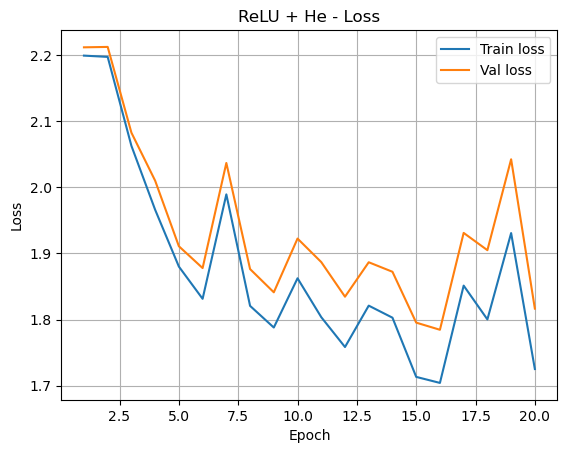

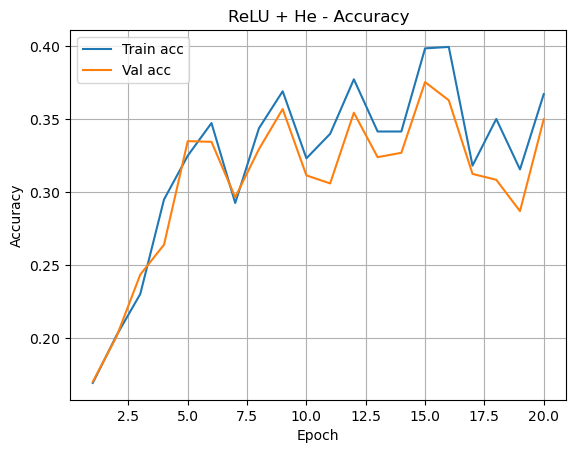

In [22]:
model_relu_he = MLP_1Hidden(
    input_dim=input_dim,
    hidden_dim=128,
    output_dim=output_dim,
    activation="relu",
    init_method="he",
    lr=0.01
)

history_relu_he = train_model(
    model_relu_he,
    X_train_sub, y_train_sub_onehot, y_train_sub_labels,
    X_val,       y_val_onehot,       y_val_labels,
    epochs=20,
    batch_size=128
)

plot_history(history_relu_he, title_prefix="ReLU + He", save_prefix="relu_he")


Epoch 01: train_loss=2.1824, train_acc=0.225, val_loss=2.2176, val_acc=0.200
Epoch 02: train_loss=2.0026, train_acc=0.287, val_loss=2.0233, val_acc=0.284
Epoch 03: train_loss=2.0964, train_acc=0.231, val_loss=2.1266, val_acc=0.232
Epoch 04: train_loss=1.8805, train_acc=0.334, val_loss=1.9155, val_acc=0.331
Epoch 05: train_loss=2.1333, train_acc=0.254, val_loss=2.1762, val_acc=0.247
Epoch 06: train_loss=1.8914, train_acc=0.316, val_loss=1.9404, val_acc=0.299
Epoch 07: train_loss=2.0029, train_acc=0.284, val_loss=2.0287, val_acc=0.290
Epoch 08: train_loss=1.7747, train_acc=0.376, val_loss=1.8258, val_acc=0.365
Epoch 09: train_loss=1.7999, train_acc=0.360, val_loss=1.8612, val_acc=0.350
Epoch 10: train_loss=1.8632, train_acc=0.354, val_loss=1.9347, val_acc=0.340
Epoch 11: train_loss=1.8907, train_acc=0.321, val_loss=1.9585, val_acc=0.306
Epoch 12: train_loss=1.8477, train_acc=0.330, val_loss=1.9154, val_acc=0.314
Epoch 13: train_loss=1.9453, train_acc=0.307, val_loss=2.0119, val_acc=0.303

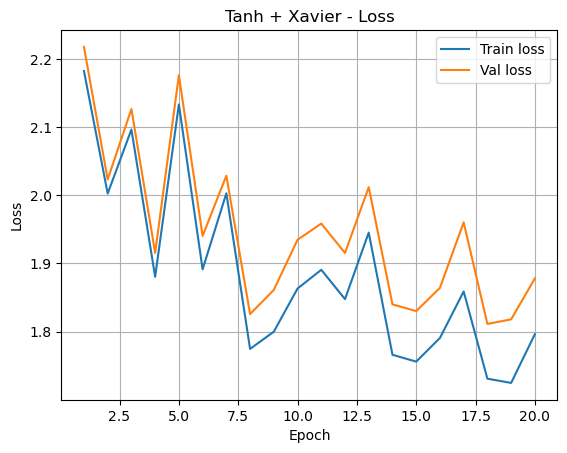

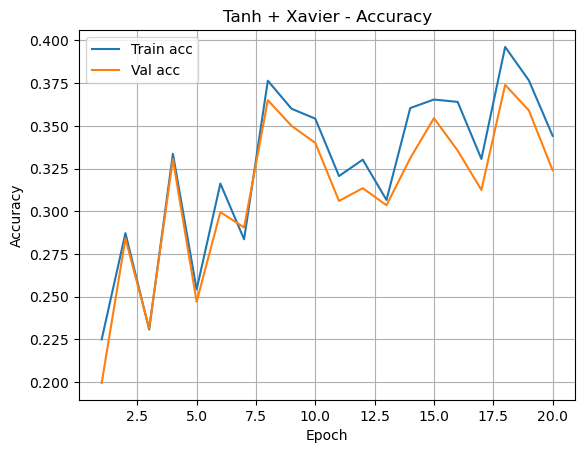

In [23]:
model_tanh_xav = MLP_1Hidden(
    input_dim=input_dim,
    hidden_dim=128,
    output_dim=output_dim,
    activation="tanh",
    init_method="xavier",
    lr=0.01
)

history_tanh_xav = train_model(
    model_tanh_xav,
    X_train_sub, y_train_sub_onehot, y_train_sub_labels,
    X_val,       y_val_onehot,       y_val_labels,
    epochs=20,
    batch_size=128
)

plot_history(history_tanh_xav, title_prefix="Tanh + Xavier", save_prefix="tanh_xavier")


Epoch 01: train_loss=2.2421, train_acc=0.191, val_loss=2.2471, val_acc=0.177
Epoch 02: train_loss=2.1892, train_acc=0.238, val_loss=2.1957, val_acc=0.235
Epoch 03: train_loss=2.1479, train_acc=0.253, val_loss=2.1571, val_acc=0.258
Epoch 04: train_loss=2.1192, train_acc=0.234, val_loss=2.1273, val_acc=0.233
Epoch 05: train_loss=2.0860, train_acc=0.290, val_loss=2.0959, val_acc=0.289
Epoch 06: train_loss=2.0652, train_acc=0.283, val_loss=2.0775, val_acc=0.286
Epoch 07: train_loss=2.0406, train_acc=0.308, val_loss=2.0550, val_acc=0.305
Epoch 08: train_loss=2.0230, train_acc=0.298, val_loss=2.0349, val_acc=0.301
Epoch 09: train_loss=2.0060, train_acc=0.329, val_loss=2.0219, val_acc=0.311
Epoch 10: train_loss=1.9910, train_acc=0.321, val_loss=2.0058, val_acc=0.317
Epoch 11: train_loss=1.9764, train_acc=0.326, val_loss=1.9920, val_acc=0.328
Epoch 12: train_loss=1.9638, train_acc=0.341, val_loss=1.9807, val_acc=0.336
Epoch 13: train_loss=1.9564, train_acc=0.322, val_loss=1.9726, val_acc=0.332

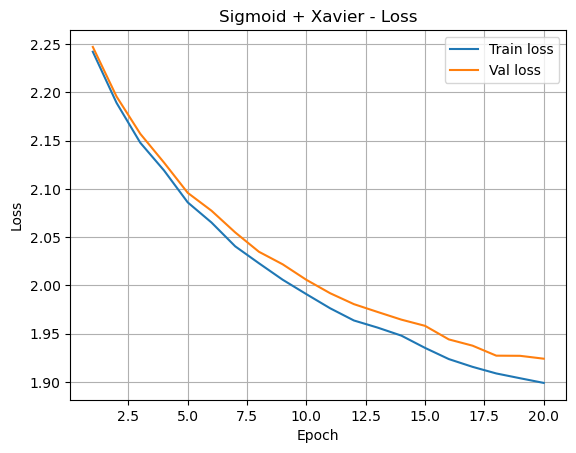

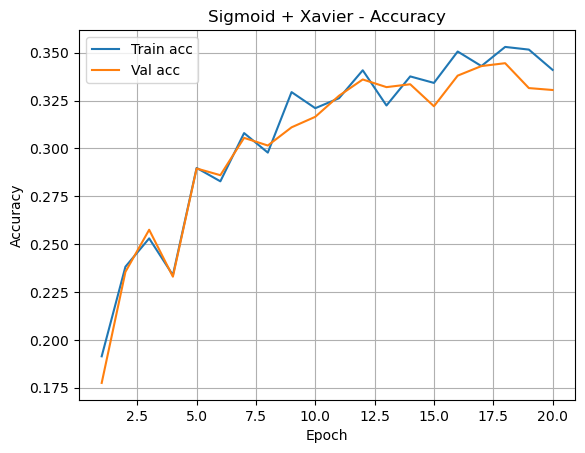

In [24]:
model_sig_xav = MLP_1Hidden(
    input_dim=input_dim,
    hidden_dim=128,
    output_dim=output_dim,
    activation="sigmoid",
    init_method="xavier",
    lr=0.01
)

history_sig_xav = train_model(
    model_sig_xav,
    X_train_sub, y_train_sub_onehot, y_train_sub_labels,
    X_val,       y_val_onehot,       y_val_labels,
    epochs=20,
    batch_size=128
)

plot_history(history_sig_xav, title_prefix="Sigmoid + Xavier", save_prefix="sigmoid_xavier")
